# Custom RF vs scikit-learn RF

This notebook benchmarks a custom Random Forest implementation against scikit-learn using the same feature pipeline and train/validation split.

Compared metrics:
- Fit time
- Predict time
- Macro F1 and accuracy
- Per-class classification report

In [ ]:
from pathlib import Path
import time
import random

import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier

from custom_random_forest import CustomRandomForestClassifier

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

PROJECT_DIR = Path.cwd().resolve()
if PROJECT_DIR.name == 'notebooks':
    PROJECT_DIR = PROJECT_DIR.parent

DATASET_DIR = PROJECT_DIR / 'data' / 'new_dataset'
TARGET_CLASSES = [1, 2, 3, 4]
CLASS_NAMES = {1: 'Greenery', 2: 'Sand', 3: 'Water', 4: 'Cement'}
EPS = 1e-6

In [2]:
image_paths = sorted(DATASET_DIR.glob('*_img.tif'))
mask_paths = sorted(DATASET_DIR.glob('*_msk.tif'))

def sample_id(path):
    return path.name.replace('_img.tif', '').replace('_msk.tif', '')

img_lookup = {sample_id(p): p for p in image_paths}
msk_lookup = {sample_id(p): p for p in mask_paths}
paired_ids = sorted(set(img_lookup) & set(msk_lookup))
pairs = [(img_lookup[sid], msk_lookup[sid]) for sid in paired_ids]

print(f'Paired samples: {len(pairs)}')
print(f'Unmatched images: {len(set(img_lookup) - set(msk_lookup))}')
print(f'Unmatched masks: {len(set(msk_lookup) - set(img_lookup))}')

Paired samples: 571
Unmatched images: 1
Unmatched masks: 0


In [3]:
def build_features(image_cube):
    # Existing 14 channels are already in image cube
    base = np.moveaxis(image_cube, 0, -1).reshape(-1, image_cube.shape[0])

    b2 = base[:, 0]
    b3 = base[:, 1]
    b4 = base[:, 2]
    b8 = base[:, 6]
    b11 = base[:, 8]
    b12 = base[:, 9]

    ratios = np.stack([
        b8 / (b4 + EPS),
        b4 / (b3 + EPS),
        b8 / (b11 + EPS),
        b11 / (b12 + EPS),
        b2 / (b3 + EPS),
    ], axis=1)

    return np.concatenate([base, ratios], axis=1).astype(np.float32)

def collect_stratified_pixels(paired_paths, target_per_class=20000, per_patch_cap=250, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    order = np.arange(len(paired_paths))
    rng.shuffle(order)

    X_chunks = []
    y_chunks = []
    collected = {c: 0 for c in TARGET_CLASSES}

    for idx in order:
        img_path, msk_path = paired_paths[idx]

        with rasterio.open(img_path) as src:
            image_cube = src.read().astype(np.float32)
        with rasterio.open(msk_path) as src:
            mask = src.read(1).astype(np.int32)

        feats = build_features(image_cube)
        mask_flat = mask.reshape(-1)

        for cls in TARGET_CLASSES:
            remaining = target_per_class - collected[cls]
            if remaining <= 0:
                continue

            cls_idx = np.where(mask_flat == cls)[0]
            if cls_idx.size == 0:
                continue

            take = min(remaining, per_patch_cap, cls_idx.size)
            chosen = rng.choice(cls_idx, size=take, replace=False)

            X_chunks.append(feats[chosen])
            y_chunks.append(np.full(take, cls, dtype=np.int32))
            collected[cls] += int(take)

        if all(collected[c] >= target_per_class for c in TARGET_CLASSES):
            break

    X = np.vstack(X_chunks).astype(np.float32)
    y = np.concatenate(y_chunks).astype(np.int32)

    print('Collected per class:')
    for c in TARGET_CLASSES:
        print(f'  {c} ({CLASS_NAMES[c]}): {collected[c]:,}')

    return X, y

X, y = collect_stratified_pixels(pairs, target_per_class=20000, per_patch_cap=250)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'X_train: {X_train.shape}, X_val: {X_val.shape}')

Collected per class:
  1 (Greenery): 20,000
  2 (Sand): 20,000
  3 (Water): 20,000
  4 (Cement): 20,000
X_train: (64000, 19), X_val: (16000, 19)


In [4]:
# Same params for both implementations
rf_params = dict(
    n_estimators=120,
    max_depth=24,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    bootstrap=True,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

custom_rf = CustomRandomForestClassifier(**rf_params)
sklearn_rf = RandomForestClassifier(**rf_params)

results = []
models = [
    ('CustomRandomForest', custom_rf),
    ('SklearnRandomForest', sklearn_rf),
]

for model_name, model in models:
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    fit_time = time.perf_counter() - t0

    t1 = time.perf_counter()
    y_pred = model.predict(X_val)
    predict_time = time.perf_counter() - t1

    metrics = {
        'model': model_name,
        'accuracy': accuracy_score(y_val, y_pred),
        'macro_f1': f1_score(y_val, y_pred, labels=TARGET_CLASSES, average='macro'),
        'fit_time_sec': fit_time,
        'predict_time_sec': predict_time
    }
    results.append((metrics, y_pred))

comparison_df = pd.DataFrame([entry[0] for entry in results]).sort_values('macro_f1', ascending=False)
comparison_df

,model,accuracy,macro_f1,fit_time_sec,predict_time_sec
1,SklearnRandomForest,0.911000,0.911245,2.090032,0.025012
0,CustomRandomForest,0.910563,0.910800,5.126996,0.182933


In [5]:
for (metrics, y_pred) in results:
    print('=' * 70)
    print(metrics['model'])
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"Macro F1: {metrics['macro_f1']:.4f}")
    print(f"Fit time (s): {metrics['fit_time_sec']:.3f}")
    print(f"Predict time (s): {metrics['predict_time_sec']:.3f}")
    print('Classification report:')
    print(classification_report(
        y_val,
        y_pred,
        labels=TARGET_CLASSES,
        target_names=[CLASS_NAMES[c] for c in TARGET_CLASSES],
        zero_division=0
    ))

CustomRandomForest
Accuracy: 0.9106
Macro F1: 0.9108
Fit time (s): 5.127
Predict time (s): 0.183
Classification report:
              precision    recall  f1-score   support

    Greenery       0.88      0.90      0.89      4000
        Sand       0.95      0.91      0.93      4000
       Water       0.99      0.99      0.99      4000
      Cement       0.83      0.84      0.84      4000

    accuracy                           0.91     16000
   macro avg       0.91      0.91      0.91     16000
weighted avg       0.91      0.91      0.91     16000

SklearnRandomForest
Accuracy: 0.9110
Macro F1: 0.9112
Fit time (s): 2.090
Predict time (s): 0.025
Classification report:
              precision    recall  f1-score   support

    Greenery       0.88      0.90      0.89      4000
        Sand       0.95      0.91      0.93      4000
       Water       0.99      0.99      0.99      4000
      Cement       0.83      0.84      0.84      4000

    accuracy                           0.91     1600

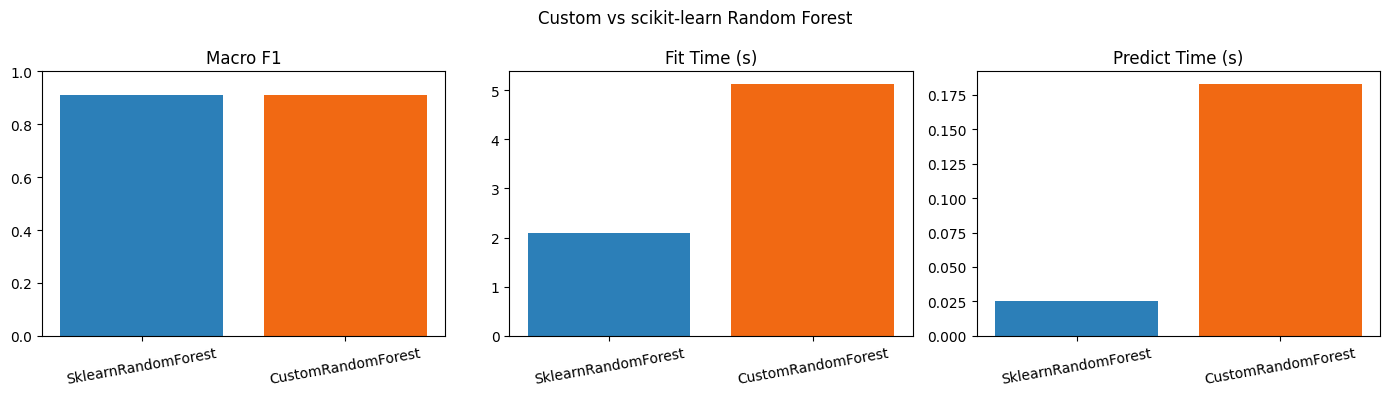

In [6]:
plot_df = comparison_df.copy()
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(plot_df['model'], plot_df['macro_f1'], color=['#2c7fb8', '#f16913'])
axes[0].set_title('Macro F1')
axes[0].set_ylim(0, 1)

axes[1].bar(plot_df['model'], plot_df['fit_time_sec'], color=['#2c7fb8', '#f16913'])
axes[1].set_title('Fit Time (s)')

axes[2].bar(plot_df['model'], plot_df['predict_time_sec'], color=['#2c7fb8', '#f16913'])
axes[2].set_title('Predict Time (s)')

for ax in axes:
    ax.tick_params(axis='x', rotation=10)

plt.suptitle('Custom vs scikit-learn Random Forest')
plt.tight_layout()
plt.show()

In [7]:
out_path = DATASET_DIR.parent / 'rf_custom_vs_sklearn_comparison.csv'
comparison_df.to_csv(out_path, index=False)
print(f'Saved comparison table: {out_path}')

Saved comparison table: c:\satellite\project\rf_custom_vs_sklearn_comparison.csv
